In [ ]:
!pip install gdown

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gdown
import warnings
warnings.filterwarnings("ignore")
from math import radians, sin, cos, sqrt, atan2

# Data Understanding

In [ ]:
url = "https://drive.google.com/file/d/1xMD0bZ7G1Wt68Ywp9H1cv5-zW58Wdq4a/view?usp=sharing"
upload = "zomato.csv"
gdown.download(url, upload, quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1xMD0bZ7G1Wt68Ywp9H1cv5-zW58Wdq4a
To: /content/zomato.csv
100%|██████████| 6.37M/6.37M [00:00<00:00, 190MB/s]


'zomato.csv'

In [ ]:
df_zomato = pd.read_csv("/content/zomato.csv")

In [ ]:
df_zomato.head(10)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41
5,0x3af3,MUMRES15DEL03,29.0,4.5,19.176269,72.836721,19.266269,72.926721,02-04-2022,20:25,20:35,Sandstorms,Jam,2,Buffet,electric_scooter,1.0,No,Metropolitian,20
6,0x3aab,MYSRES01DEL01,35.0,4.0,12.311072,76.654878,12.351072,76.694878,01-03-2022,14:55,15:10,Windy,High,1,Meal,scooter,1.0,No,Metropolitian,33
7,0x689b,PUNERES20DEL01,33.0,4.2,18.592718,73.773572,18.702718,73.883572,16-03-2022,20:30,20:40,Sandstorms,Jam,2,Snack,motorcycle,1.0,No,Metropolitian,40
8,0x6f67,HYDRES14DEL01,34.0,4.9,17.426228,78.407495,17.496228,78.477495,20-03-2022,20:40,20:50,Cloudy,Jam,0,Snack,motorcycle,NaN,No,Metropolitian,41
9,0xc9cf,KOLRES15DEL03,21.0,4.7,22.552672,88.352885,22.582672,88.382885,15-02-2022,21:15,21:30,Windy,Jam,0,Meal,motorcycle,1.0,No,Urban,15


In [ ]:
df_zomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

In [ ]:
df_zomato["Time_Orderd"].unique()

array(['21:55', '14:55', '17:30', '09:20', '19:50', '20:25', '20:30',
       '20:40', '21:15', '20:20', '22:30', '08:15', '19:30', '12:25',
       '18:35', '20:35', '23:20', '21:20', '23:35', '22:35', '23:25',
       '13:35', '21:35', '18:55', '14:15', '0.458333333', '09:45',
       '08:40', '0.958333333', '17:25', nan, '19:45', '19:10', '10:55',
       '21:40', '0.791666667', '16:45', '11:30', '15:10', '22:45',
       '22:10', '20:45', '22:50', '17:55', '09:25', '20:15', '22:25',
       '22:40', '23:50', '15:25', '10:20', '20:55', '10:40', '15:55',
       '20:10', '12:10', '15:30', '10:35', '21:10', '20:50', '12:35',
       '0.875', '23:40', '18:15', '18:20', '11:45', '12:45', '23:30',
       '10:50', '21:25', '10:10', '17:50', '22:20', '12:40', '23:55',
       '10:25', '08:45', '23:45', '19:55', '22:15', '23:10', '09:15',
       '18:25', '18:45', '16:50', '1', '14:20', '10:15', '08:50', '0.375',
       '17:45', '16:35', '08:30', '21:45', '19:40', '14:50', '18:10',
       '12:20', '12

In [ ]:
df_zomato["Road_traffic_density"].value_counts(dropna=False)

,count
Road_traffic_density,
Low,15476
Jam,14139
Medium,10945
High,4423
NaN,601


In [ ]:
df_zomato["multiple_deliveries"].value_counts(dropna=False)

,count
multiple_deliveries,
1.0,28151
0.0,14094
2.0,1985
NaN,993
3.0,361


In [ ]:
df_zomato["Festival"].value_counts(dropna=False)

,count
Festival,
No,44460
Yes,896
NaN,228


In [ ]:
df_zomato["City"].value_counts(dropna=False)

,count
City,
Metropolitian,34087
Urban,10133
NaN,1200
Semi-Urban,164


In [ ]:
df_zomato["Type_of_vehicle"].value_counts(dropna=False)

,count
Type_of_vehicle,
motorcycle,26429
scooter,15273
electric_scooter,3814
bicycle,68


In [ ]:
df_zomato["Vehicle_condition"].value_counts(dropna=False)

,count
Vehicle_condition,
2,15031
1,15028
0,15005
3,520


In [ ]:
df_zomato["Delivery_person_Ratings"].unique()

array([4.2, 4.7, 4.3, 4.5, 4. , 4.9, 4.1, 5. , 4.8, 3.5, 4.6, nan, 4.4,
       3.8, 3.9, 3.7, 2.6, 2.5, 3.6, 3.1, 2.7, 1. , 3.2, 3.3, 6. , 3.4,
       2.8, 2.9, 3. ])

# Data Quality Check

In [ ]:
df_zomato.isna().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731


In [ ]:
missing_percent = (df_zomato.isna().sum()/len(df_zomato))*100
print(missing_percent)

ID                             0.000000
Delivery_person_ID             0.000000
Delivery_person_Age            4.067217
Delivery_person_Ratings        4.185679
Restaurant_latitude            0.000000
Restaurant_longitude           0.000000
Delivery_location_latitude     0.000000
Delivery_location_longitude    0.000000
Order_Date                     0.000000
Time_Orderd                    3.797385
Time_Order_picked              0.000000
Weather_conditions             1.351351
Road_traffic_density           1.318445
Vehicle_condition              0.000000
Type_of_order                  0.000000
Type_of_vehicle                0.000000
multiple_deliveries            2.178396
Festival                       0.500176
City                           2.632503
Time_taken (min)               0.000000
dtype: float64


In [ ]:
df_zomato.duplicated().sum()

np.int64(0)

In [ ]:
df_zomato["Delivery_person_Ratings"].describe()

,Delivery_person_Ratings
count,43676.000000
mean,4.633774
std,0.334744
min,1.000000
25%,4.500000
50%,4.700000
75%,4.900000
max,6.000000


In [ ]:
df_zomato["Delivery_person_Age"].describe()

,Delivery_person_Age
count,43730.000000
mean,29.566911
std,5.815064
min,15.000000
25%,25.000000
50%,30.000000
75%,35.000000
max,50.000000


In [ ]:
df_zomato["Time_taken (min)"].describe()

,Time_taken (min)
count,45584.000000
mean,26.293963
std,9.384298
min,10.000000
25%,19.000000
50%,26.000000
75%,32.000000
max,54.000000


# Cleaning Data

In [ ]:
df_zomato.columns = df_zomato.columns.str.strip().str.lower().str.replace(" ", "_")

In [ ]:
df_zomato = df_zomato.replace("NaN ", np.nan)
df_zomato = df_zomato.replace("Nan", np.nan)

In [ ]:
for col in df_zomato.select_dtypes(include="object"):
  df_zomato[col] = df_zomato[col].str.strip()

In [ ]:
df_zomato["order_date"] = pd.to_datetime(df_zomato["order_date"], format="mixed")

In [ ]:
def convert_mixed_time(x):
  try:

    # jika null
    if pd.isna(x):
      return np.nan

    # convert ke string
    x_str = str(x).strip()

    # jika format HH:MM
    if ":" in x_str:
      return x_str

    # jika numeric decimal / integer
    x_float = float(x_str)
    total_minutes = int(x_float * 24 * 60)
    hours = (total_minutes // 60) % 24
    minutes = total_minutes % 60

    return f"{hours:02d}:{minutes:02d}"

  except:
    return np.nan

In [ ]:
df_zomato["time_orderd"] = df_zomato["time_orderd"].apply(convert_mixed_time)

In [ ]:
df_zomato["time_orderd"].unique()

array(['21:55', '14:55', '17:30', '09:20', '19:50', '20:25', '20:30',
       '20:40', '21:15', '20:20', '22:30', '08:15', '19:30', '12:25',
       '18:35', '20:35', '23:20', '21:20', '23:35', '22:35', '23:25',
       '13:35', '21:35', '18:55', '14:15', '10:59', '09:45', '08:40',
       '22:59', '17:25', nan, '19:45', '19:10', '10:55', '21:40', '19:00',
       '16:45', '11:30', '15:10', '22:45', '22:10', '20:45', '22:50',
       '17:55', '09:25', '20:15', '22:25', '22:40', '23:50', '15:25',
       '10:20', '20:55', '10:40', '15:55', '20:10', '12:10', '15:30',
       '10:35', '21:10', '20:50', '12:35', '21:00', '23:40', '18:15',
       '18:20', '11:45', '12:45', '23:30', '10:50', '21:25', '10:10',
       '17:50', '22:20', '12:40', '23:55', '10:25', '08:45', '23:45',
       '19:55', '22:15', '23:10', '09:15', '18:25', '18:45', '16:50',
       '00:00', '14:20', '10:15', '08:50', '09:00', '17:45', '16:35',
       '08:30', '21:45', '19:40', '14:50', '18:10', '12:20', '12:50',
       '09:10',

In [ ]:
df_zomato["time_orderd"] = pd.to_datetime(
    df_zomato["time_orderd"], format="%H:%M", errors="coerce"
).dt.time

df_zomato["time_order_picked"] = pd.to_datetime(
    df_zomato["time_order_picked"], format="%H:%M", errors="coerce"
).dt.time

In [ ]:
df_zomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           45584 non-null  object        
 1   delivery_person_id           45584 non-null  object        
 2   delivery_person_age          43730 non-null  float64       
 3   delivery_person_ratings      43676 non-null  float64       
 4   restaurant_latitude          45584 non-null  float64       
 5   restaurant_longitude         45584 non-null  float64       
 6   delivery_location_latitude   45584 non-null  float64       
 7   delivery_location_longitude  45584 non-null  float64       
 8   order_date                   45584 non-null  datetime64[ns]
 9   time_orderd                  43853 non-null  object        
 10  time_order_picked            40577 non-null  object        
 11  weather_conditions           44968 non-nu

In [ ]:
df_zomato["time_order_picked"].unique()

array([datetime.time(22, 10), datetime.time(15, 5), datetime.time(17, 40),
       datetime.time(9, 30), datetime.time(20, 5), datetime.time(20, 35),
       datetime.time(15, 10), datetime.time(20, 40),
       datetime.time(20, 50), datetime.time(21, 30),
       datetime.time(20, 25), datetime.time(22, 45), datetime.time(8, 30),
       datetime.time(19, 45), datetime.time(12, 30),
       datetime.time(18, 50), datetime.time(23, 30),
       datetime.time(21, 35), datetime.time(23, 45),
       datetime.time(22, 50), datetime.time(22, 40),
       datetime.time(23, 35), datetime.time(13, 40),
       datetime.time(21, 45), datetime.time(19, 10),
       datetime.time(14, 25), datetime.time(11, 10), datetime.time(9, 55),
       datetime.time(8, 55), datetime.time(23, 10), datetime.time(17, 30),
       datetime.time(18, 35), datetime.time(19, 50),
       datetime.time(19, 25), NaT, datetime.time(19, 15),
       datetime.time(16, 55), datetime.time(11, 40),
       datetime.time(15, 15), datetime

In [ ]:
# drop row
df_zomato = df_zomato.dropna(subset=["time_orderd"]).copy()

In [ ]:
df_zomato.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43853 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           43853 non-null  object        
 1   delivery_person_id           43853 non-null  object        
 2   delivery_person_age          43639 non-null  float64       
 3   delivery_person_ratings      43585 non-null  float64       
 4   restaurant_latitude          43853 non-null  float64       
 5   restaurant_longitude         43853 non-null  float64       
 6   delivery_location_latitude   43853 non-null  float64       
 7   delivery_location_longitude  43853 non-null  float64       
 8   order_date                   43853 non-null  datetime64[ns]
 9   time_orderd                  43853 non-null  object        
 10  time_order_picked            39045 non-null  object        
 11  weather_conditions           43853 non-null  o

In [ ]:
numeric_cols = [
    "delivery_person_age",
    "delivery_person_ratings",
    "multiple_deliveries"
]

for col in numeric_cols:
  df_zomato[col] = pd.to_numeric(df_zomato[col], errors="coerce")

In [ ]:
# numerical
df_zomato["delivery_person_age"] = df_zomato["delivery_person_age"].fillna(
    df_zomato["delivery_person_age"].median()
)

df_zomato["delivery_person_ratings"] = df_zomato["delivery_person_ratings"].fillna(
    df_zomato["delivery_person_ratings"].median()
)

df_zomato["multiple_deliveries"] = df_zomato["multiple_deliveries"].fillna(
    df_zomato["multiple_deliveries"].median()
)

In [ ]:
df_zomato["festival"].value_counts(dropna=False)

,count
festival,
No,42777
Yes,857
NaN,219


In [ ]:
# categorical
df_zomato["weather_conditions"] = df_zomato["weather_conditions"].fillna(
    df_zomato["weather_conditions"].mode()[0]
)

df_zomato["festival"] = df_zomato["festival"].fillna(
    "No"
)

df_zomato["city"] = df_zomato["city"].fillna(
    df_zomato["city"].mode()[0]
)

In [ ]:
#df_zomato["road_traffic_density"] = (
 #   df_zomato.groupby("city")["road_traffic_density"].transform(
  #      lambda x: x.fillna(x.mode()[0])
   # )
#)

In [ ]:
df_zomato["road_traffic_density"].unique()

array(['Jam', 'High', 'Medium', 'Low'], dtype=object)

In [ ]:
df_zomato.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43853 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           43853 non-null  object        
 1   delivery_person_id           43853 non-null  object        
 2   delivery_person_age          43853 non-null  float64       
 3   delivery_person_ratings      43853 non-null  float64       
 4   restaurant_latitude          43853 non-null  float64       
 5   restaurant_longitude         43853 non-null  float64       
 6   delivery_location_latitude   43853 non-null  float64       
 7   delivery_location_longitude  43853 non-null  float64       
 8   order_date                   43853 non-null  datetime64[ns]
 9   time_orderd                  43853 non-null  object        
 10  time_order_picked            39045 non-null  object        
 11  weather_conditions           43853 non-null  o

In [ ]:
df_zomato.isna().sum()

,0
id,0
delivery_person_id,0
delivery_person_age,0
delivery_person_ratings,0
restaurant_latitude,0
restaurant_longitude,0
delivery_location_latitude,0
delivery_location_longitude,0
order_date,0
time_orderd,0


In [ ]:
df_zomato.describe(include="object")

,id,delivery_person_id,time_orderd,time_order_picked,weather_conditions,road_traffic_density,type_of_order,type_of_vehicle,festival,city
count,43853,43853,43853,39045,43853,43853,43853,43853,43853,43853
unique,43853,1320,176,174,6,4,4,3,2,3
top,0x5fb2,JAPRES11DEL02,21:55:00,21:30:00,Fog,Low,Snack,motorcycle,No,Metropolitian
freq,1,65,461,483,7475,15061,11088,25627,42996,33940


In [ ]:
df_zomato.describe()

,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,vehicle_condition,multiple_deliveries,time_taken_(min)
count,43853.000000,43853.000000,43853.000000,43853.000000,43853.000000,43853.000000,43853,43853.000000,43853.000000,43853.000000
mean,29.556952,4.635676,17.242245,70.763328,17.462771,70.826921,2022-04-20 11:50:51.294096384,1.000912,0.749595,26.293161
min,20.000000,2.500000,-30.902872,0.000000,0.010000,0.010000,2022-01-03 00:00:00,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.986229,73.279083,2022-03-04 00:00:00,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.554382,75.898497,18.633934,75.999490,2022-03-24 00:00:00,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.103162,2022-05-03 00:00:00,2.000000,1.000000,32.000000
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-12-03 00:00:00,2.000000,3.000000,54.000000
std,5.747386,0.312931,7.699200,21.138033,7.338998,21.138202,NaN,0.816543,0.567630,9.374274


In [ ]:
df_zomato[
    df_zomato["restaurant_longitude"] == 0
].head(20)

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_(min)
24,0x2876,RANCHIRES02DEL01,32.0,3.5,0.0,0.0,0.11,0.11,2022-08-03,21:35:00,21:45:00,Stormy,Jam,1,Snack,scooter,0.0,No,Urban,35
43,0xc1ff,AURGRES20DEL03,25.0,5.0,0.0,0.0,0.03,0.03,2022-02-13,22:10:00,22:25:00,Cloudy,Low,0,Snack,motorcycle,0.0,No,Metropolitian,15
48,0x8e6c,VADRES02DEL02,39.0,4.2,0.0,0.0,0.08,0.08,2022-02-03,20:35:00,20:50:00,Fog,Jam,2,Snack,scooter,1.0,No,Semi-Urban,49
50,0x395b,VADRES04DEL03,36.0,4.7,0.0,0.0,0.06,0.06,2022-03-13,20:15:00,20:20:00,Cloudy,Jam,1,Snack,motorcycle,1.0,No,Metropolitian,30
58,0x98aa,VADRES16DEL02,23.0,4.8,0.0,0.0,0.02,0.02,2022-07-03,10:40:00,10:50:00,Stormy,Low,1,Meal,scooter,1.0,No,Metropolitian,15
59,0x273a,VADRES09DEL01,35.0,4.8,0.0,0.0,0.04,0.04,2022-03-28,15:55:00,16:05:00,Fog,Medium,2,Buffet,scooter,1.0,No,Urban,16
63,0x5ded,VADRES15DEL02,24.0,4.8,0.0,0.0,0.08,0.08,2022-03-25,22:10:00,22:15:00,Sandstorms,Low,1,Buffet,motorcycle,1.0,No,Urban,15
64,0x1a70,MYSRES14DEL02,29.0,4.7,0.0,0.0,0.02,0.02,2022-09-03,10:35:00,10:45:00,Fog,Low,0,Buffet,motorcycle,1.0,No,Metropolitian,17
67,0xc606,BHPRES12DEL02,20.0,4.5,0.0,0.0,0.05,0.05,2022-11-02,21:10:00,21:25:00,Fog,Jam,1,Drinks,motorcycle,1.0,No,Metropolitian,27
72,0xc444,DEHRES01DEL01,30.0,4.8,0.0,0.0,0.11,0.11,2022-02-16,23:40:00,23:55:00,Windy,Low,1,Snack,motorcycle,1.0,No,Metropolitian,25


In [ ]:
(df_zomato["restaurant_longitude"] == 0).sum()

np.int64(3509)

In [ ]:
df_zomato[
    (df_zomato["delivery_person_ratings"] < 0)
    |
    (df_zomato["delivery_person_ratings"] > 5)
]

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_(min)


In [ ]:
df_zomato[
    (df_zomato["delivery_person_age"] < 18)
    |
    (df_zomato["delivery_person_age"] > 60)
]

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_(min)


<Axes: xlabel='time_taken_(min)'>

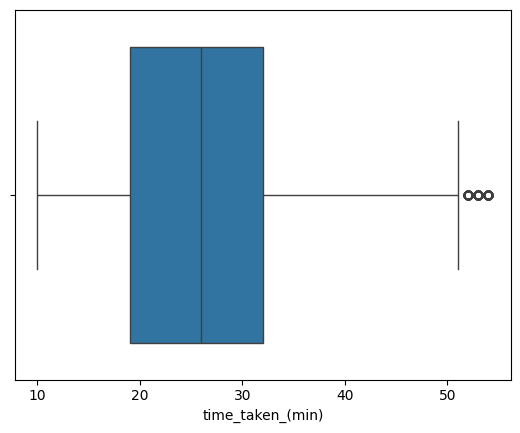

In [ ]:
sns.boxplot(x=df_zomato["time_taken_(min)"])

In [ ]:
q1 = df_zomato["time_taken_(min)"].quantile(0.25)
q3 = df_zomato["time_taken_(min)"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

In [ ]:
outlier = df_zomato[
    (df_zomato["time_taken_(min)"] < lower)
    |
    (df_zomato["time_taken_(min)"] > upper)
]

In [ ]:
outlier

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken_(min)
34,0xb796,SURRES17DEL03,37.0,4.7,21.149569,72.772697,21.239569,72.862697,2022-04-04,19:45:00,19:50:00,Sandstorms,Jam,0,Snack,motorcycle,3.0,No,Metropolitian,52
179,0x4b5b,MYSRES04DEL03,38.0,4.3,12.308500,76.665808,12.398500,76.755808,2022-04-04,21:15:00,21:25:00,Sandstorms,Jam,0,Meal,motorcycle,1.0,Yes,Semi-Urban,54
257,0xd92f,AGRRES03DEL01,35.0,4.9,27.160832,78.011608,27.230832,78.081608,2022-02-18,21:15:00,21:30:00,Cloudy,Jam,0,Buffet,motorcycle,2.0,No,Metropolitian,53
632,0xc2ba,LUDHRES18DEL03,20.0,3.9,30.890184,75.829615,30.950184,75.889615,2022-11-02,20:40:00,20:45:00,Sunny,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,54
713,0x836d,HYDRES06DEL01,31.0,4.4,17.455894,78.375467,17.525894,78.445467,2022-03-25,19:35:00,19:40:00,Stormy,Jam,0,Meal,motorcycle,1.0,Yes,Metropolitian,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44780,0xd0f,SURRES02DEL02,31.0,4.0,21.186608,72.794136,21.316608,72.924136,2022-03-18,20:35:00,20:40:00,Stormy,Jam,0,Meal,motorcycle,0.0,Yes,Urban,53
45034,0xb839,MUMRES15DEL02,39.0,4.4,19.176269,72.836721,19.256269,72.916721,2022-02-04,21:00:00,21:05:00,Sandstorms,Jam,0,Meal,motorcycle,1.0,No,Metropolitian,54
45176,0x3c6e,HYDRES08DEL01,27.0,3.7,17.438263,78.397865,17.478263,78.437865,2022-03-13,12:10:00,12:15:00,Sunny,High,0,Buffet,motorcycle,1.0,No,Semi-Urban,52
45285,0x713d,JAPRES07DEL02,39.0,4.4,26.766536,75.837333,26.896536,75.967333,2022-03-18,21:35:00,21:45:00,Sandstorms,Jam,0,Drinks,motorcycle,1.0,No,Metropolitian,53


In [ ]:
df_zomato["is_delayed_extreme"] = (
    df_zomato["time_taken_(min)"] > upper
)

In [ ]:
pd.crosstab(
    df_zomato["road_traffic_density"], df_zomato["is_delayed_extreme"]
)

is_delayed_extreme,False,True
road_traffic_density,,
High,4297,23
Jam,13564,232
Low,15061,0
Medium,10676,0


In [ ]:
df_zomato["invalid_coordinate"] = (
    (df_zomato["restaurant_latitude"] == 0)
    |
    (df_zomato["restaurant_longitude"] == 0)
)

In [ ]:
df_zomato["invalid_coordinate"].value_counts()

,count
invalid_coordinate,
False,40344
True,3509


# Feature Engineering

In [ ]:
# pickup delay
df_pickup = df_zomato.dropna(
    subset=["time_orderd", "time_order_picked"]
).copy()

In [ ]:
df_pickup["pickup_delay_min"] = (
    pd.to_datetime(df_pickup["time_order_picked"].astype(str), format="%H:%M:%S")
    -
    pd.to_datetime(df_pickup["time_orderd"].astype(str), format="%H:%M:%S")
).dt.total_seconds() / 60

In [ ]:
df_pickup.describe()

,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,vehicle_condition,multiple_deliveries,time_taken_(min),pickup_delay_min
count,39045.000000,39045.000000,39045.000000,39045.000000,39045.000000,39045.000000,39045,39045.000000,39045.000000,39045.000000,39045.000000
mean,29.567653,4.635654,17.240861,70.770534,17.465151,70.833854,2022-04-20 12:55:51.333077248,1.000307,0.751185,26.370957,9.983071
min,20.000000,2.500000,-30.902872,0.000000,0.010000,0.010000,2022-01-03 00:00:00,0.000000,0.000000,10.000000,5.000000
25%,25.000000,4.500000,12.933298,73.170283,12.988453,73.280283,2022-03-04 00:00:00,0.000000,0.000000,19.000000,5.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633481,76.003106,2022-03-24 00:00:00,1.000000,1.000000,26.000000,10.000000
75%,35.000000,4.900000,22.732225,78.046106,22.785207,78.109117,2022-05-03 00:00:00,2.000000,1.000000,32.000000,15.000000
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-12-03 00:00:00,2.000000,3.000000,54.000000,16.000000
std,5.751649,0.312257,7.708697,21.131322,7.339472,21.131563,NaN,0.817197,0.568884,9.395974,4.089580


In [ ]:
# order hour untuk peak-hour analysis
df_zomato["order_hour"] = pd.to_datetime(
    df_zomato["time_orderd"].astype(str), format="%H:%M:%S"
).dt.hour

In [ ]:
df_zomato["order_hour"].describe()

,order_hour
count,43853.000000
mean,17.396757
std,4.811293
min,0.000000
25%,15.000000
50%,19.000000
75%,21.000000
max,23.000000


In [ ]:
df_zomato["order_hour"].unique()

array([21, 14, 17,  9, 19, 20, 22,  8, 12, 18, 23, 13, 10, 16, 11, 15,  0],
      dtype=int32)

In [ ]:
# day of week
df_zomato["day_of_week"] = (
    df_zomato["order_date"].dt.day_name()
)

In [ ]:
# feature weekend
df_zomato["is_weekend"] = (
    df_zomato["day_of_week"].isin(["Saturday", "Sunday"])
)

In [ ]:
df_zomato["is_weekend"].describe()

,is_weekend
count,43853
unique,2
top,False
freq,32670


In [ ]:
# saat distance analysis
df_distance = df_zomato[
    df_zomato["invalid_coordinate"] == False
].copy()

In [ ]:
df_distance.head()

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,...,type_of_vehicle,multiple_deliveries,festival,city,time_taken_(min),is_delayed_extreme,invalid_coordinate,order_hour,day_of_week,is_weekend
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-12-02,21:55:00,...,motorcycle,3.0,No,Metropolitian,46,False,False,21,Friday,False
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55:00,...,motorcycle,1.0,No,Metropolitian,23,False,False,14,Sunday,True
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-04-03,17:30:00,...,scooter,1.0,No,Metropolitian,21,False,False,17,Sunday,True
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20:00,...,motorcycle,0.0,No,Metropolitian,20,False,False,9,Sunday,True
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50:00,...,scooter,1.0,No,Metropolitian,41,False,False,19,Monday,False


In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
  R = 6371
  lat1, lon1, lat2, lon2 = map(
      radians,
      [lat1, lon1, lat2, lon2]
  )
  dlat = lat2 - lat1
  dlon = lon2 - lon1
  a = (
      sin(dlat / 2) ** 2
      +
      cos(lat1)
      * cos(lat2)
      * sin(dlon / 2) ** 2
  )
  c = 2 * atan2(sqrt(a), sqrt(1 - a))
  distance = R * c
  return distance

In [ ]:
df_distance["delivery_distance_km"] = df_distance.apply(
    lambda row: haversine_distance(
        row["restaurant_latitude"],
        row["restaurant_longitude"],
        row["delivery_location_latitude"],
        row["delivery_location_longitude"]
    ),
    axis=1
)

In [ ]:
df_distance["delivery_distance_km"].describe()

,delivery_distance_km
count,40344.000000
mean,28.673485
std,315.965666
min,1.465067
25%,4.657673
50%,9.206322
75%,13.681487
max,6884.726399


In [ ]:
# cek outlier distance
q1 = df_distance["delivery_distance_km"].quantile(0.25)
q3 = df_distance["delivery_distance_km"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

In [ ]:
print(upper)

27.217208957404054


In [ ]:
outlier = df_distance[
    (df_distance["delivery_distance_km"] < lower)
    |
    (df_distance["delivery_distance_km"] > upper)
]

outlier["delivery_distance_km"].describe()

,delivery_distance_km
count,156.000000
mean,4912.290324
std,1371.032845
min,2216.065794
25%,4421.166849
50%,5021.474291
75%,5895.928471
max,6884.726399


In [ ]:
outlier[
    [
        "restaurant_latitude",
        "restaurant_longitude",
        "delivery_location_latitude",
        "delivery_location_longitude",
        "delivery_distance_km"
    ]
].head(10)

,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,delivery_distance_km
83,-27.163303,78.057044,27.233303,78.127044,6048.631240
274,-27.165108,78.015053,27.225108,78.075053,6047.919478
1082,-15.546594,73.760431,15.606594,73.820431,3464.082720
1774,-23.230791,77.437020,23.250791,77.457020,5168.516553
1967,-22.539129,88.365507,22.549129,88.375507,5013.585658
2092,-15.157944,73.950889,15.197944,73.990889,3375.423601
2129,-9.959778,76.296106,9.969778,76.306106,2216.065794
2191,-15.513150,73.783460,15.563150,73.833460,3455.531261
2289,-15.576683,73.755750,15.646683,73.825750,3471.888400
2627,-30.902872,75.826808,30.972872,75.896808,6880.272782


In [ ]:
# iqr filter
df_distance_clean = df_distance[
    (df_distance["delivery_distance_km"] >= lower)
    &
    (df_distance["delivery_distance_km"] <= upper)
].copy()

In [ ]:
df_distance_clean = df_distance[
    df_distance["delivery_distance_km"] <= 50
]

In [ ]:
df_distance_clean["delivery_distance_km"].describe()

,delivery_distance_km
count,40188.000000
mean,9.716477
std,5.597959
min,1.465067
25%,4.657655
50%,9.193021
75%,13.631449
max,20.969489


In [ ]:
df_distance_clean[
    ["delivery_distance_km", "time_taken_(min)"]
].corr()

,delivery_distance_km,time_taken_(min)
delivery_distance_km,1.000000,0.321341
time_taken_(min),0.321341,1.000000


In [ ]:
# peak hour flag
def peak_hour_flag(hour):
  if 11 <= hour <= 14:
    return "Lunch Peak"
  elif 18 <= hour <= 21:
    return "Dinner Peak"
  else:
    return "Off Peak"

In [ ]:
df_zomato["peak_hour_flag"] = (
    df_zomato["order_hour"].apply(peak_hour_flag)
)

In [ ]:
df_zomato["peak_hour_flag"].value_counts()

,count
peak_hour_flag,
Off Peak,21324
Dinner Peak,18295
Lunch Peak,4234


In [ ]:
# peak hour category
def peak_category(hour):
  if 6 <= hour <= 10:
    return "Breakfast"
  elif 11 <= hour <= 14:
    return "Lunch"
  elif 15 <= hour <= 17:
    return "Afternoon"
  elif 18 <= hour <= 21:
    return "Dinner"
  else:
    return "Night"

In [ ]:
# peak hour category
df_zomato["peak_hour_category"] = (
    df_zomato["order_hour"].apply(peak_category)
)

In [ ]:
df_zomato["peak_hour_category"].value_counts()

,count
peak_hour_category,
Dinner,18295
Night,9517
Breakfast,5948
Afternoon,5859
Lunch,4234


In [ ]:
# delivery speed category
def delivery_speed_category(x):
  if x < 20:
    return "Fast"
  elif x <= 40:
    return "Moderate"
  else:
    return "Delayed"

In [ ]:
df_zomato["delivery_speed_category"] = (
    df_zomato["time_taken_(min)"]
    .apply(delivery_speed_category)
)

In [ ]:
df_zomato["delivery_speed_category"].value_counts()

,count
delivery_speed_category,
Moderate,27967
Fast,12013
Delayed,3873


In [ ]:
df_zomato.describe()

,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,vehicle_condition,multiple_deliveries,time_taken_(min),order_hour
count,43853.000000,43853.000000,43853.000000,43853.000000,43853.000000,43853.000000,43853,43853.000000,43853.000000,43853.000000,43853.000000
mean,29.556952,4.635676,17.242245,70.763328,17.462771,70.826921,2022-04-20 11:50:51.294096384,1.000912,0.749595,26.293161,17.396757
min,20.000000,2.500000,-30.902872,0.000000,0.010000,0.010000,2022-01-03 00:00:00,0.000000,0.000000,10.000000,0.000000
25%,25.000000,4.500000,12.933298,73.170283,12.986229,73.279083,2022-03-04 00:00:00,0.000000,0.000000,19.000000,15.000000
50%,30.000000,4.700000,18.554382,75.898497,18.633934,75.999490,2022-03-24 00:00:00,1.000000,1.000000,26.000000,19.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.103162,2022-05-03 00:00:00,2.000000,1.000000,32.000000,21.000000
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-12-03 00:00:00,2.000000,3.000000,54.000000,23.000000
std,5.747386,0.312931,7.699200,21.138033,7.338998,21.138202,NaN,0.816543,0.567630,9.374274,4.811293


In [ ]:
df_distance.describe()

,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,vehicle_condition,multiple_deliveries,time_taken_(min),order_hour,delivery_distance_km
count,40344.000000,40344.000000,40344.000000,40344.000000,40344.000000,40344.000000,40344,40344.000000,40344.000000,40344.000000,40344.000000,40344.000000
mean,29.554581,4.634379,18.741924,76.918110,18.976140,76.981743,2022-04-20 07:55:55.859607296,0.999901,0.750000,26.311918,17.394408,28.673485
min,20.000000,2.500000,-30.902872,72.768726,9.967144,72.778726,2022-01-03 00:00:00,0.000000,0.000000,10.000000,0.000000,1.465067
25%,25.000000,4.500000,12.981615,73.897902,13.065996,73.940327,2022-03-04 00:00:00,0.000000,0.000000,19.000000,15.000000,4.657673
50%,30.000000,4.700000,19.055831,76.618203,19.124049,76.662278,2022-03-24 00:00:00,1.000000,1.000000,26.000000,19.000000,9.206322
75%,35.000000,4.900000,22.750040,78.368855,22.820040,78.403391,2022-05-03 00:00:00,2.000000,1.000000,32.000000,21.000000,13.681487
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-12-03 00:00:00,2.000000,3.000000,54.000000,23.000000,6884.726399
std,5.746596,0.314001,6.027109,3.500607,5.470145,3.500816,NaN,0.816203,0.567408,9.371971,4.809135,315.965666


In [ ]:
df_pickup.describe()

,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,vehicle_condition,multiple_deliveries,time_taken_(min),pickup_delay_min
count,39045.000000,39045.000000,39045.000000,39045.000000,39045.000000,39045.000000,39045,39045.000000,39045.000000,39045.000000,39045.000000
mean,29.567653,4.635654,17.240861,70.770534,17.465151,70.833854,2022-04-20 12:55:51.333077248,1.000307,0.751185,26.370957,9.983071
min,20.000000,2.500000,-30.902872,0.000000,0.010000,0.010000,2022-01-03 00:00:00,0.000000,0.000000,10.000000,5.000000
25%,25.000000,4.500000,12.933298,73.170283,12.988453,73.280283,2022-03-04 00:00:00,0.000000,0.000000,19.000000,5.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633481,76.003106,2022-03-24 00:00:00,1.000000,1.000000,26.000000,10.000000
75%,35.000000,4.900000,22.732225,78.046106,22.785207,78.109117,2022-05-03 00:00:00,2.000000,1.000000,32.000000,15.000000
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-12-03 00:00:00,2.000000,3.000000,54.000000,16.000000
std,5.751649,0.312257,7.708697,21.131322,7.339472,21.131563,NaN,0.817197,0.568884,9.395974,4.089580


In [ ]:
df_zomato["road_traffic_density"].value_counts()

,count
road_traffic_density,
Low,15061
Jam,13796
Medium,10676
High,4320


In [ ]:
df_zomato["weather_conditions"].value_counts()

,count
weather_conditions,
Fog,7475
Stormy,7400
Cloudy,7336
Sandstorms,7284
Windy,7251
Sunny,7107


In [ ]:
df_zomato["multiple_deliveries"].value_counts()

,count
multiple_deliveries,
1.0,28003
0.0,13587
2.0,1920
3.0,343


In [ ]:
df_zomato["peak_hour_flag"].value_counts()

,count
peak_hour_flag,
Off Peak,21324
Dinner Peak,18295
Lunch Peak,4234


In [ ]:
df_distance_clean["delivery_distance_km"].value_counts()

,count
delivery_distance_km,
13.682045,18
13.763977,18
9.314907,18
1.509480,18
1.489781,18
...,...
13.216893,1
1.488324,1
13.893865,1


In [ ]:
df_pickup["pickup_delay_min"].value_counts()

,count
pickup_delay_min,
5.0,12843
10.0,12561
15.0,12437
11.0,425
16.0,406
6.0,373


# EDA

In [ ]:
df_distance_feature = df_distance_clean[
    ["id", "delivery_distance_km"]
]

df_pickup_feature = df_pickup[
    ["id", "pickup_delay_min"]
]

In [ ]:
df_final = df_zomato.merge(
    df_distance_feature,
    on="id",
    how="left"
)

df_final = df_final.merge(
    df_pickup_feature,
    on="id",
    how="left"
)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43853 entries, 0 to 43852
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           43853 non-null  object        
 1   delivery_person_id           43853 non-null  object        
 2   delivery_person_age          43853 non-null  float64       
 3   delivery_person_ratings      43853 non-null  float64       
 4   restaurant_latitude          43853 non-null  float64       
 5   restaurant_longitude         43853 non-null  float64       
 6   delivery_location_latitude   43853 non-null  float64       
 7   delivery_location_longitude  43853 non-null  float64       
 8   order_date                   43853 non-null  datetime64[ns]
 9   time_orderd                  43853 non-null  object        
 10  time_order_picked            39045 non-null  object        
 11  weather_conditions           43853 non-nu

In [ ]:
missing = df_final.isna().sum()
missing[missing > 0]

,0
time_order_picked,4808
delivery_distance_km,3665
pickup_delay_min,4808


In [ ]:
df_final.groupby(
    "peak_hour_flag"
)["time_taken_(min)"].mean()

,time_taken_(min)
peak_hour_flag,
Dinner Peak,30.113528
Lunch Peak,27.231696
Off Peak,22.829113


In [ ]:
pd.crosstab(
    df_final["peak_hour_flag"],
    df_final["is_delayed_extreme"]
)

is_delayed_extreme,False,True
peak_hour_flag,,
Dinner Peak,18068,227
Lunch Peak,4211,23
Off Peak,21319,5


In [ ]:
pd.crosstab(
    df_final["peak_hour_flag"],
    df_final["road_traffic_density"]
)

road_traffic_density,High,Jam,Low,Medium
peak_hour_flag,,,,
Dinner Peak,0,13392,0,4903
Lunch Peak,4234,0,0,0
Off Peak,86,404,15061,5773


In [ ]:
df_final.groupby(
    "road_traffic_density"
)["time_taken_(min)"].mean()

,time_taken_(min)
road_traffic_density,
High,27.208565
Jam,31.153740
Low,21.277140
Medium,26.717966


In [ ]:
df_final.groupby(
    "multiple_deliveries"
)["time_taken_(min)"].mean()

,time_taken_(min)
multiple_deliveries,
0.0,22.864944
1.0,26.723780
2.0,40.427604
3.0,47.816327


In [ ]:
pd.crosstab(
    df_final["multiple_deliveries"],
    df_final["is_delayed_extreme"]
)

is_delayed_extreme,False,True
multiple_deliveries,,
0.0,13552,35
1.0,27893,110
2.0,1876,44
3.0,277,66


In [ ]:
df_final.groupby(
    "weather_conditions"
)["time_taken_(min)"].mean()

,time_taken_(min)
weather_conditions,
Cloudy,28.939477
Fog,28.930435
Sandstorms,25.890719
Stormy,25.856486
Sunny,21.847334
Windy,26.104537


In [ ]:
pd.crosstab(
    df_final["city"],
    df_final["peak_hour_flag"]
)

peak_hour_flag,Dinner Peak,Lunch Peak,Off Peak
city,,,
Metropolitian,14667,3324,15949
Semi-Urban,134,16,6
Urban,3494,894,5369


In [ ]:
pd.crosstab(
    df_final["city"],
    df_final["is_delayed_extreme"]
)

is_delayed_extreme,False,True
city,,
Metropolitian,33759,181
Semi-Urban,104,52
Urban,9735,22


In [ ]:
pd.crosstab(
    df_final["weather_conditions"],
    df_final["is_delayed_extreme"]
)

is_delayed_extreme,False,True
weather_conditions,,
Cloudy,7293,43
Fog,7418,57
Sandstorms,7252,32
Stormy,7367,33
Sunny,7058,49
Windy,7210,41


In [ ]:
# avg delivery by traffic
df_final.groupby(
    "road_traffic_density"
)["time_taken_(min)"].mean()

,time_taken_(min)
road_traffic_density,
High,27.208565
Jam,31.153740
Low,21.277140
Medium,26.717966


In [ ]:
pd.crosstab(
    df_final["road_traffic_density"],
    df_final["is_delayed_extreme"]
)

is_delayed_extreme,False,True
road_traffic_density,,
High,4297,23
Jam,13564,232
Low,15061,0
Medium,10676,0


In [ ]:
corr = df_final.corr(numeric_only=True)
corr

,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,vehicle_condition,multiple_deliveries,time_taken_(min),is_delayed_extreme,invalid_coordinate,order_hour,is_weekend,delivery_distance_km,pickup_delay_min
delivery_person_age,1.000000,-0.117448,0.001408,0.000090,0.002449,0.000088,-0.001906,0.115187,0.303061,0.036005,0.001399,-0.000381,0.002190,-0.001137,-0.009201
delivery_person_ratings,-0.117448,1.000000,-0.012124,-0.013485,-0.013478,-0.013672,0.048850,-0.123712,-0.359751,-0.035363,0.014050,-0.061662,0.005339,-0.108016,0.003768
restaurant_latitude,0.001408,-0.012124,1.000000,0.650109,0.935340,0.650162,-0.001751,0.007633,0.015243,0.001739,-0.660473,0.005785,-0.011919,0.018644,-0.006030
restaurant_longitude,0.000090,-0.013485,0.650109,1.000000,0.690755,0.999998,-0.003807,0.003874,0.008073,-0.002398,-0.987304,-0.001619,0.011716,0.000373,-0.006362
delivery_location_latitude,0.002449,-0.013478,0.935340,0.690755,1.000000,0.690817,-0.000711,0.008468,0.014815,0.000430,-0.699215,0.009176,-0.017832,0.025357,-0.007174
delivery_location_longitude,0.000088,-0.013672,0.650162,0.999998,0.690817,1.000000,-0.003794,0.004089,0.008631,-0.002314,-0.987302,-0.000619,0.011638,0.010884,-0.006365
vehicle_condition,-0.001906,0.048850,-0.001751,-0.003807,-0.000711,-0.003794,1.000000,-0.100712,-0.243176,-0.093747,0.004200,0.002543,0.003255,0.008468,0.007083
multiple_deliveries,0.115187,-0.123712,0.007633,0.003874,0.008468,0.004089,-0.100712,1.000000,0.379195,0.108238,-0.002418,0.066672,-0.009929,0.121503,-0.001304
time_taken_(min),0.303061,-0.359751,0.015243,0.008073,0.014815,0.008631,-0.243176,0.379195,1.000000,0.218301,-0.006784,0.185051,-0.023169,0.321341,-0.003598
is_delayed_extreme,0.036005,-0.035363,0.001739,-0.002398,0.000430,-0.002314,-0.093747,0.108238,0.218301,1.000000,0.002869,0.032404,-0.000019,0.047776,-0.006022


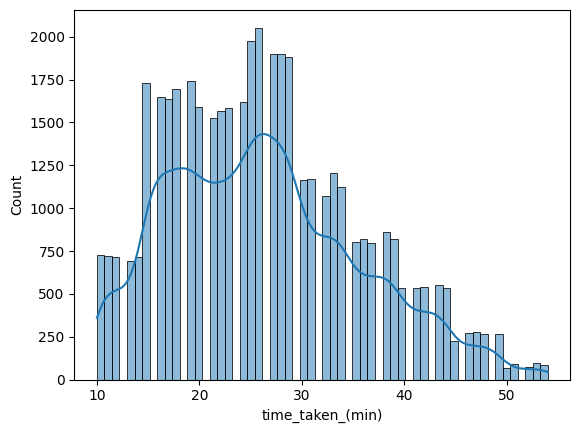

In [ ]:
sns.histplot(
    df_final["time_taken_(min)"],
    kde=True
)
plt.show()

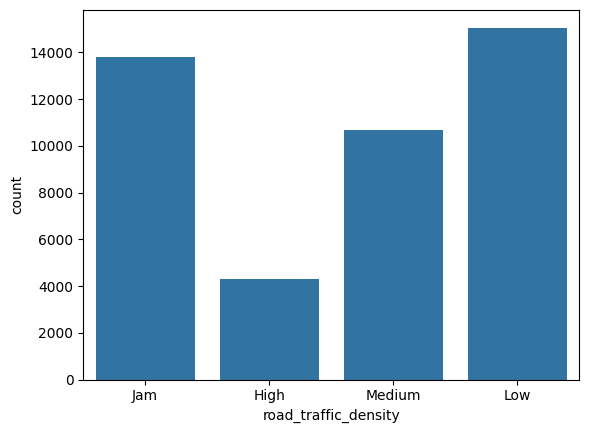

In [ ]:
sns.countplot(
    data=df_final,
    x="road_traffic_density"
)
plt.show()

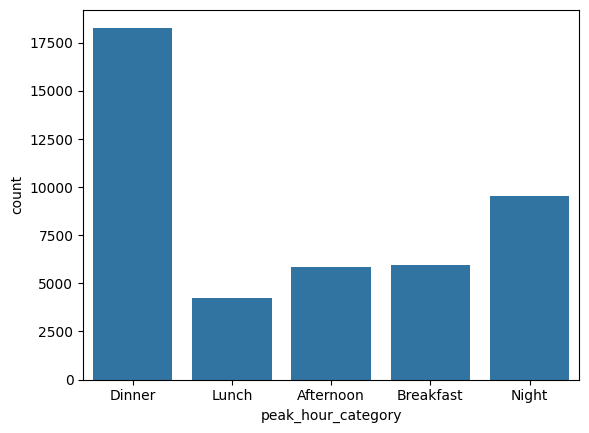

In [ ]:
sns.countplot(
    data=df_final,
    x="peak_hour_category"
)
plt.show()

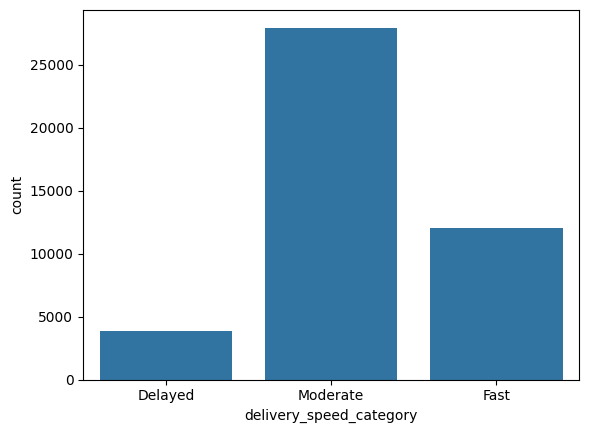

In [ ]:
sns.countplot(
    data=df_final,
    x="delivery_speed_category"
)
plt.show()

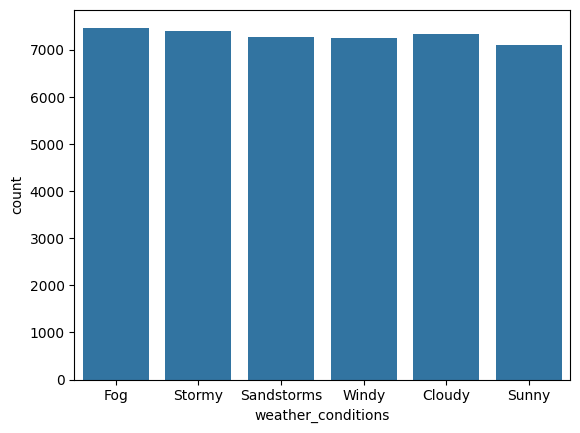

In [ ]:
sns.countplot(
    data=df_final,
    x="weather_conditions"
)
plt.show()

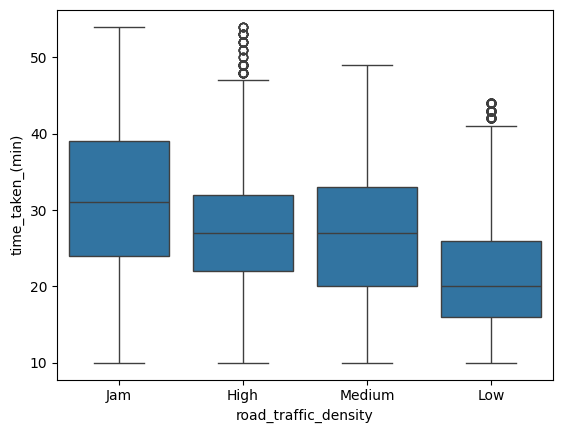

In [ ]:
# traffic
sns.boxplot(
    data=df_final,
    x="road_traffic_density",
    y="time_taken_(min)"
)
plt.show()

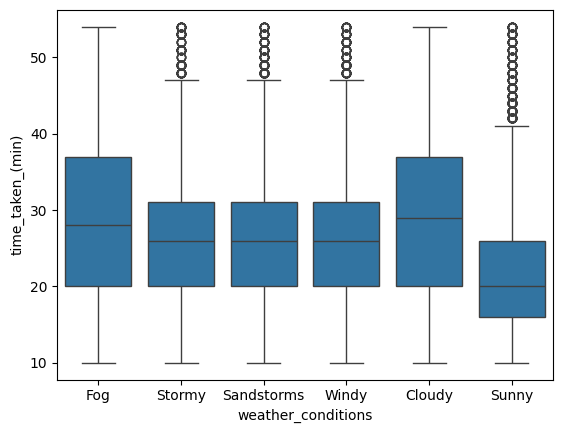

In [ ]:
# weather mempengaruhi bottleneck
sns.boxplot(
    x="weather_conditions",
    y="time_taken_(min)",
    data=df_final
)
plt.show()

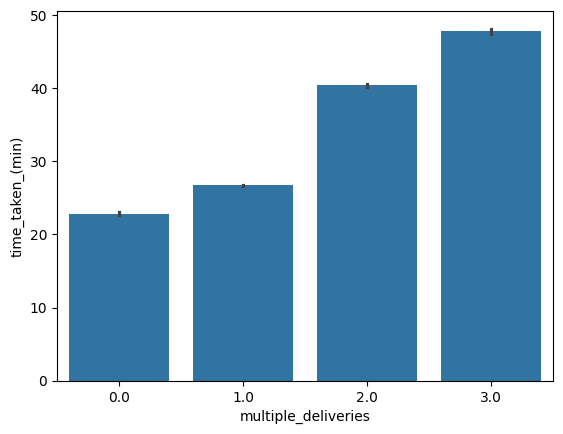

In [ ]:
# worload driver mempengaruhi delay
sns.barplot(
    data=df_final,
    x="multiple_deliveries",
    y="time_taken_(min)"
)
plt.show()

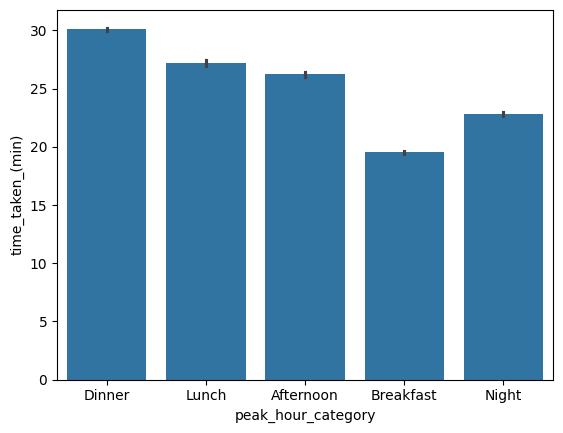

In [ ]:
# rush hour bottleneck
sns.barplot(
    x="peak_hour_category",
    y="time_taken_(min)",
    data=df_final
)
plt.show()

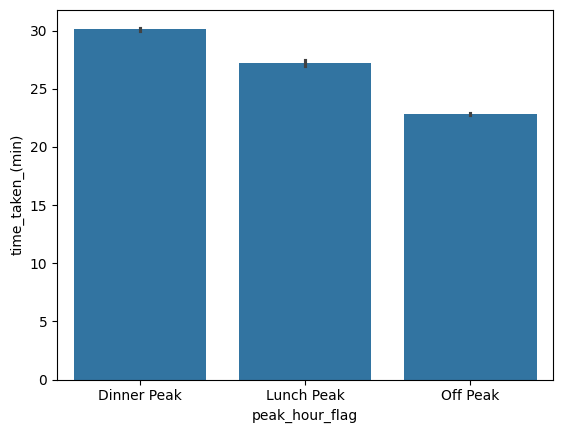

In [ ]:
# rush hour bottleneck
sns.barplot(
    x="peak_hour_flag",
    y="time_taken_(min)",
    data=df_final
)
plt.show()

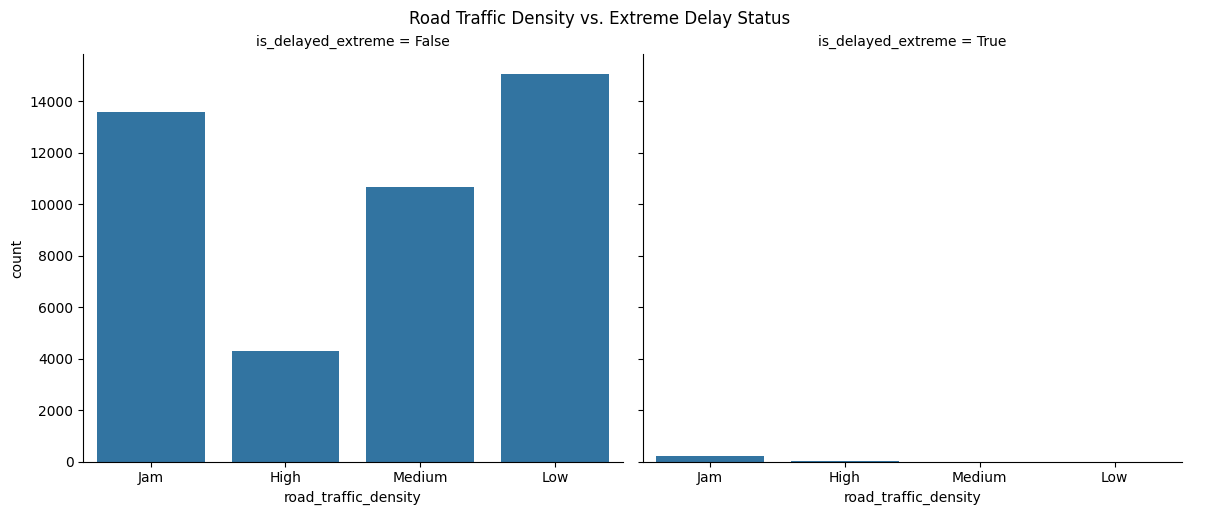

In [ ]:
sns.catplot(
    x="road_traffic_density",
    col="is_delayed_extreme", # memisahkan plot True/False
    kind="count",
    data=df_final,
    height=5,
    aspect=1.2 # Adjust aspect ratio for better readability
)
plt.suptitle('Road Traffic Density vs. Extreme Delay Status', y=1.02) # menambahkan judul
plt.show()

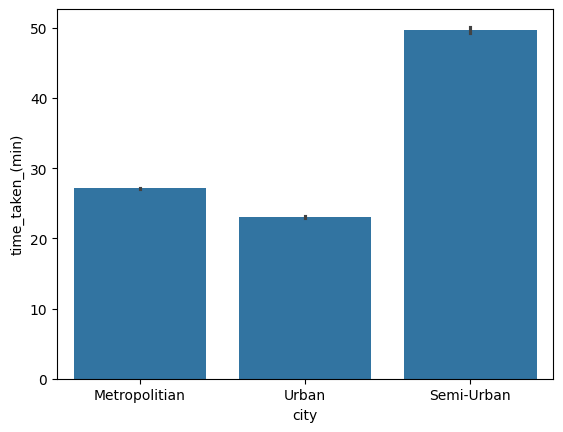

In [ ]:
sns.barplot(
    x="city",
    y="time_taken_(min)",
    data=df_final
)
plt.show()

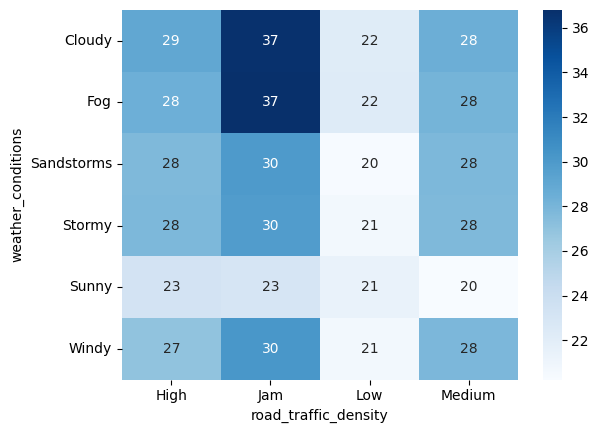

In [ ]:
pivot = df_final.pivot_table(
    values="time_taken_(min)",
    index="weather_conditions",
    columns="road_traffic_density",
    aggfunc="mean"
)
sns.heatmap(pivot, annot=True, cmap="Blues")
plt.show()

In [ ]:
fitur = [
    "delivery_distance_km",
    "multiple_deliveries",
    "pickup_delay_min",
    "time_taken_(min)",
    "order_hour"
]

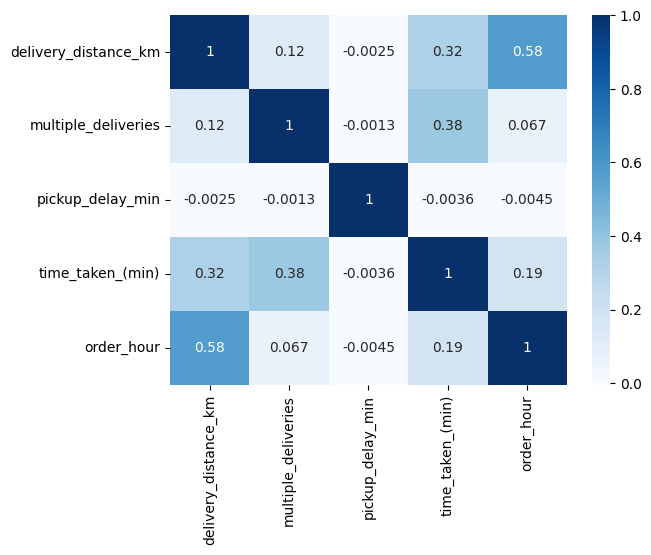

In [ ]:
df_corr_data = df_final[fitur]
corr = df_corr_data.corr()
sns.heatmap(corr, annot=True, cmap="Blues")
plt.show()

## Distance Analysis

In [ ]:
# Distance analysis
df_distance_analysis = df_final.dropna(
    subset=["delivery_distance_km"]
)

In [ ]:
df_distance_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40188 entries, 0 to 43852
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           40188 non-null  object        
 1   delivery_person_id           40188 non-null  object        
 2   delivery_person_age          40188 non-null  float64       
 3   delivery_person_ratings      40188 non-null  float64       
 4   restaurant_latitude          40188 non-null  float64       
 5   restaurant_longitude         40188 non-null  float64       
 6   delivery_location_latitude   40188 non-null  float64       
 7   delivery_location_longitude  40188 non-null  float64       
 8   order_date                   40188 non-null  datetime64[ns]
 9   time_orderd                  40188 non-null  object        
 10  time_order_picked            35782 non-null  object        
 11  weather_conditions           40188 non-null  o

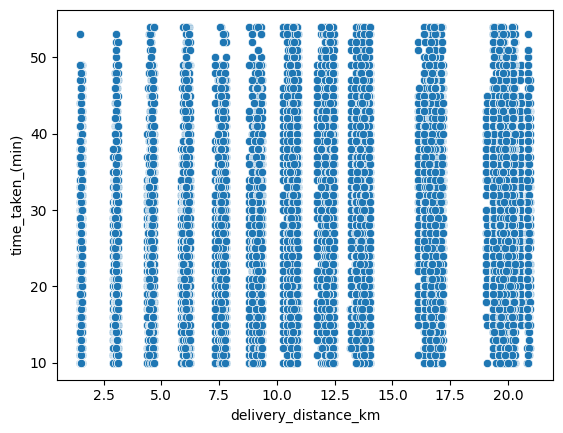

In [ ]:
sns.scatterplot(
    x="delivery_distance_km",
    y="time_taken_(min)",
    data=df_distance_analysis
)
plt.show()

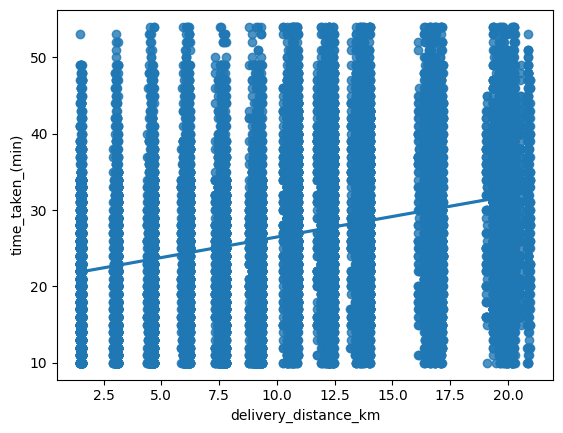

In [ ]:
sns.regplot(
    x="delivery_distance_km",
    y="time_taken_(min)",
    data=df_distance_analysis
)
plt.show()

## Pickup Analysis

In [ ]:
df_pickup_analysis = df_final.dropna(
    subset=["pickup_delay_min"]
)

In [ ]:
df_pickup_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39045 entries, 0 to 43852
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           39045 non-null  object        
 1   delivery_person_id           39045 non-null  object        
 2   delivery_person_age          39045 non-null  float64       
 3   delivery_person_ratings      39045 non-null  float64       
 4   restaurant_latitude          39045 non-null  float64       
 5   restaurant_longitude         39045 non-null  float64       
 6   delivery_location_latitude   39045 non-null  float64       
 7   delivery_location_longitude  39045 non-null  float64       
 8   order_date                   39045 non-null  datetime64[ns]
 9   time_orderd                  39045 non-null  object        
 10  time_order_picked            39045 non-null  object        
 11  weather_conditions           39045 non-null  o

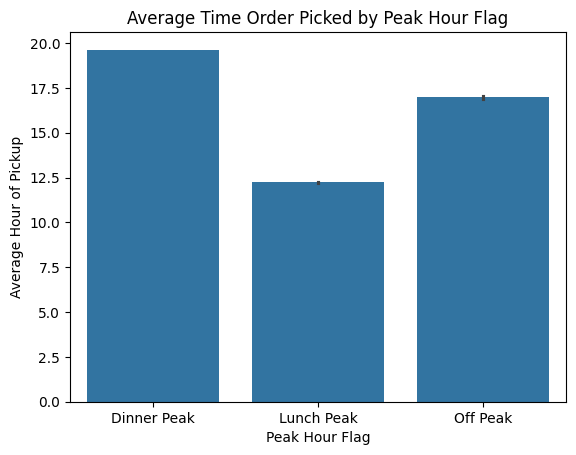

In [ ]:
df_pickup_analysis['time_order_picked_hour'] = df_pickup_analysis['time_order_picked'].apply(lambda x: x.hour)
sns.barplot(
    x="peak_hour_flag",
    y="time_order_picked_hour",
    data=df_pickup_analysis
)
plt.title('Average Time Order Picked by Peak Hour Flag')
plt.xlabel('Peak Hour Flag')
plt.ylabel('Average Hour of Pickup')
plt.show()

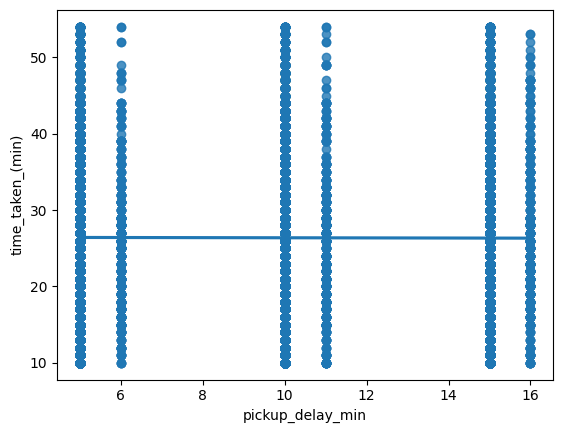

In [ ]:
# restaurant bottleneck
sns.regplot(
    x="pickup_delay_min",
    y="time_taken_(min)",
    data=df_pickup_analysis
)
plt.show()

### EDA: Congestion Period Identification

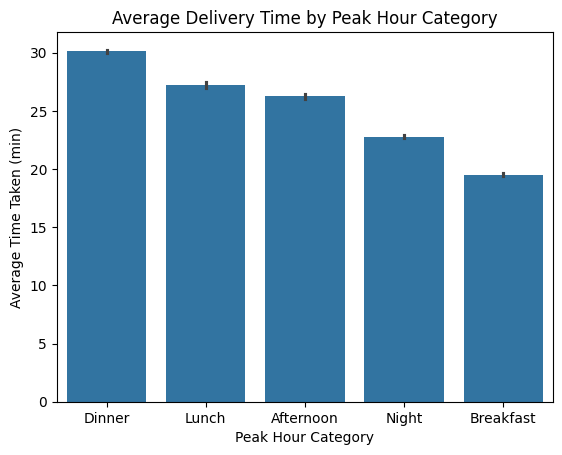

In [ ]:
# Average 'Time_taken (min)' by 'peak_hour_category'
sns.barplot(
    x="peak_hour_category",
    y="time_taken_(min)",
    data=df_final,
    order=df_final.groupby('peak_hour_category')['time_taken_(min)'].mean().sort_values(ascending=False).index
)
plt.title('Average Delivery Time by Peak Hour Category')
plt.xlabel('Peak Hour Category')
plt.ylabel('Average Time Taken (min)')
plt.show()

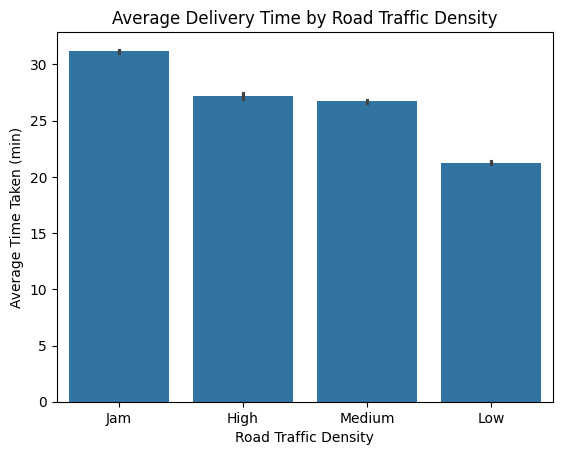

In [ ]:
# Average 'Time_taken (min)' by 'road_traffic_density'
sns.barplot(
    x="road_traffic_density",
    y="time_taken_(min)",
    data=df_final,
    order=df_final.groupby('road_traffic_density')['time_taken_(min)'].mean().sort_values(ascending=False).index
)
plt.title('Average Delivery Time by Road Traffic Density')
plt.xlabel('Road Traffic Density')
plt.ylabel('Average Time Taken (min)')
plt.show()

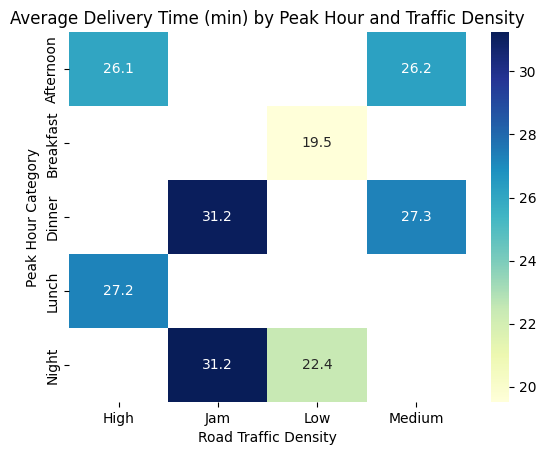

In [ ]:
# Heatmap: Average 'Time_taken (min)' by 'peak_hour_category' and 'road_traffic_density'
pivot_congestion = df_final.pivot_table(
    values="time_taken_(min)",
    index="peak_hour_category",
    columns="road_traffic_density",
    aggfunc="mean"
)
sns.heatmap(pivot_congestion, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title('Average Delivery Time (min) by Peak Hour and Traffic Density')
plt.xlabel('Road Traffic Density')
plt.ylabel('Peak Hour Category')
plt.show()

# Scoring Category

In [ ]:
df_final["delivery_distance_km"].describe()

,delivery_distance_km
count,40188.000000
mean,9.716477
std,5.597959
min,1.465067
25%,4.657655
50%,9.193021
75%,13.631449
max,20.969489


In [ ]:
def calculate_risk_score(row):
  score = 0

  # traffic density
  if row["road_traffic_density"] == "Jam":
    score += 3
  elif row["road_traffic_density"] == "High":
    score += 2
  elif row["road_traffic_density"] == "Medium":
    score += 1

  # multiple deliveries
  if row["multiple_deliveries"] == 1:
    score += 1
  elif row["multiple_deliveries"] == 2:
    score += 2
  elif row["multiple_deliveries"] == 3:
    score += 3

  # peak hour
  if row["peak_hour_flag"] == "Dinner Peak":
    score += 2
  elif row["peak_hour_flag"] == "Lunch Peak":
    score += 1

  # delivery distance
  if pd.notna(row["delivery_distance_km"]):
    if row["delivery_distance_km"] > 15:
      score += 2
    elif row["delivery_distance_km"] > 10:
      score += 1

  # pickup delay
  if pd.notna(row["pickup_delay_min"]):
    if row["pickup_delay_min"] > 15:
      score += 2
    elif row["pickup_delay_min"] > 10:
      score += 1

  # weather
  if row["weather_conditions"] in [
      "Fog",
      "Stormy",
      "Sandstorms"
  ]:
       score += 2
  elif row["weather_conditions"] == "Windy":
      score += 1

  return score

In [ ]:
df_final["risk_score"] = (
    df_final.apply(calculate_risk_score, axis=1
    )
)

In [ ]:
df_final["risk_score"].describe()

,risk_score
count,43853.000000
mean,5.150548
std,2.707519
min,0.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,14.000000


In [ ]:
df_final["risk_score"].value_counts().sort_index()

,count
risk_score,
0,936
1,2631
2,4409
3,6137
4,5727
5,4698
6,4901
7,4395
8,4270


In [ ]:
# Category Scoring
def operational_risk_category(score):
  if score >= 8:
    return "High Risk"
  elif score >= 4:
    return "Medium Risk"
  else:
    return "Low Risk"

In [ ]:
df_final["operational_risk_category"] = (
    df_final["risk_score"].apply(
        operational_risk_category
    )
)

In [ ]:
df_final["operational_risk_category"].value_counts()

,count
operational_risk_category,
Medium Risk,19721
Low Risk,14113
High Risk,10019


In [ ]:
df_final.groupby(
    "operational_risk_category"
)["time_taken_(min)"].mean()

,time_taken_(min)
operational_risk_category,
High Risk,32.954686
Low Risk,21.100687
Medium Risk,26.624765


In [ ]:
pd.crosstab(
    df_final["operational_risk_category"],
    df_final["is_delayed_extreme"]
)

is_delayed_extreme,False,True
operational_risk_category,,
High Risk,9822,197
Low Risk,14113,0
Medium Risk,19663,58


In [ ]:
pd.crosstab(
    df_final["operational_risk_category"],
    df_final["road_traffic_density"]
)

road_traffic_density,High,Jam,Low,Medium
operational_risk_category,,,,
High Risk,44,9152,1,822
Low Risk,305,12,11263,2533
Medium Risk,3971,4632,3797,7321


In [ ]:
pd.crosstab(
    df_final["operational_risk_category"],
    df_final["peak_hour_flag"]
)

peak_hour_flag,Dinner Peak,Lunch Peak,Off Peak
operational_risk_category,,,
High Risk,9875,44,100
Low Risk,185,284,13644
Medium Risk,8235,3906,7580


In [ ]:
pd.crosstab(
    df_final["operational_risk_category"],
    df_final["multiple_deliveries"]
)

multiple_deliveries,0.0,1.0,2.0,3.0
operational_risk_category,,,,
High Risk,1424,7065,1237,293
Low Risk,6735,7328,50,0
Medium Risk,5428,13610,633,50


In [ ]:
df_final.to_csv("df.csv", index=False)

In [ ]:
print(f"Number of unique order IDs: {df_final['id'].nunique()}")
print(f"Total number of rows in df_final: {len(df_final)}")

Number of unique order IDs: 43853
Total number of rows in df_final: 43853
